## Installing the Packages

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *    # COntains Helper functions
import copy, math

---

## Getting Familiar with Dataset

### View The variables

In [18]:
X_train, y_train = load_data("ex2data2.txt")

print("Type of X_train:",type(X_train))
print("First five elements in X_train are:\n", X_train[:5])

Type of X_train: <class 'numpy.ndarray'>
First five elements in X_train are:
 [[ 0.051267  0.69956 ]
 [-0.092742  0.68494 ]
 [-0.21371   0.69225 ]
 [-0.375     0.50219 ]
 [-0.51325   0.46564 ]]


In [19]:
print("Type of y_train:",type(y_train))
print("First five elements in y_train are:\n", y_train[:5])

Type of y_train: <class 'numpy.ndarray'>
First five elements in y_train are:
 [1. 1. 1. 1. 1.]


### Checking the dimensions

In [20]:
print ('The shape of X_train is: ' + str(X_train.shape))
print ('The shape of y_train is: ' + str(y_train.shape))
print (f'We have m = {len(y_train)} training examples')

The shape of X_train is: (118, 2)
The shape of y_train is: (118,)
We have m = 118 training examples


### Vizualizing the data

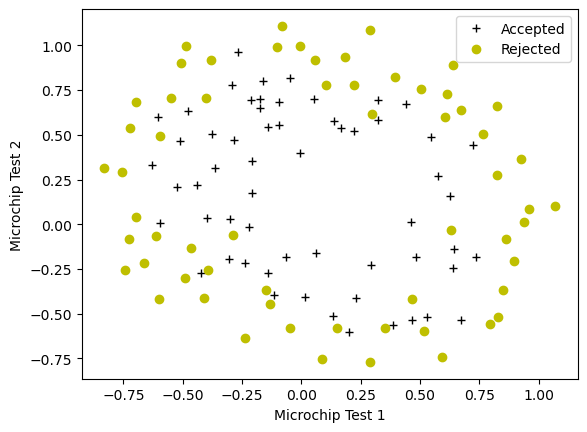

In [33]:
plot_data(X_train, y_train[:], pos_label="Accepted", neg_label="Rejected")

plt.ylabel('Microchip Test 2') 
plt.xlabel('Microchip Test 1') 
plt.legend(loc="upper right")
plt.show()

---

## Sigmoid Function

For logistic regression, the model is represented as

$$ f_{\mathbf{w},b}(x) = g(\mathbf{w}\cdot \mathbf{x} + b)$$
where function $g$ is the sigmoid function. The sigmoid function is defined as:

$$g(z) = \frac{1}{1+e^{-z}}$$

In [34]:
def sigmoid(z):
    g = 1/(1+ np.exp(-z))
    return g

___

## Cost Funtion

For logistic regression, the cost function is of the form 

$$ J(\mathbf{w},b) = \frac{1}{m}\sum_{i=0}^{m-1} \left[ loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) \right] \tag{1}$$

where
- m is the number of training examples in the dataset


- $loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)})$ is the cost for a single data point, which is - 

    $$loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = (-y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \tag{2}$$
    
    
-  $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$ is the model's prediction, while $y^{(i)}$, which is the actual label

-  $f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(\mathbf{w} \cdot \mathbf{x^{(i)}} + b)$ where function $g$ is the sigmoid function.

In [35]:
def compute_cost(X, y, w, b):
    m, n = X.shape
    loss_sum = 0

    for i in range(m):
        z_wb = 0
        for j in range(n):
            z_wb_ij = w[j] * X[i][j]
            z_wb += z_wb_ij
        z_wb += b

        f_wb = sigmoid(z_wb)
        loss = -((y[i]*np.log(f_wb))+((1-y[i])*np.log(1-f_wb)))
        loss_sum += loss
    total_cost = (1/m)*loss_sum
    return total_cost

---

## Regularzied Cost function
For regularized logistic regression, the cost function is of the form
$$J(\mathbf{w},b) = \frac{1}{m}  \sum_{i=0}^{m-1} \left[ -y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \right] + \frac{\lambda}{2m}  \sum_{j=0}^{n-1} w_j^2$$

Compare this to the cost function without regularization (which you implemented above), which is of the form 

$$ J(\mathbf{w}.b) = \frac{1}{m}\sum_{i=0}^{m-1} \left[ (-y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right)\right]$$

The difference is the regularization term, which is $$\frac{\lambda}{2m}  \sum_{j=0}^{n-1} w_j^2$$ 
Note that the $b$ parameter is not regularized.

In [36]:
def compute_cost_reg(X, y, w, b, lambda_ = 1): # lambda_ ontrols amount of regularization
    m, n = X.shape
    cost_without_reg = compute_cost(X,y,w,b)
    reg_cost = 0.

    for j in range(n):
        reg_cost_j = w[j]**2
        reg_cost += reg_cost_j

    reg_cost = (lambda_/(2*m))*reg_cost
    total_cost = cost_without_reg + reg_cost
    return total_cost

---

## Gradient for logistic regression

The gradient descent algorithm is:

$$\begin{align*}& \text{repeat until convergence:} \; \lbrace \newline \; & b := b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b} \newline       \; & w_j := w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \tag{1}  \; & \text{for j := 0..n-1}\newline & \rbrace\end{align*}$$

where, parameters $b$, $w_j$ are all updated simultaniously

### Defining the compute gradient function

In [37]:
def compute_gradient(X, y, w, b):
    m, n = X.shape
    dj_dw = np.zeros(w.shape)
    dj_db = 0.

    for i in range(m):
        z_wb = 0
        for j in range(n):
            z_wb += w[j] * X[i][j]
        z_wb += b
        f_wb = sigmoid(z_wb)

        dj_db_i = f_wb - y[i]
        dj_db += dj_db_i

        for j in range(n):
            dj_dw_ij = (f_wb - y[i])*X[i][j]
            dj_dw[j] += dj_dw_ij

    dj_dw /= m
    dj_db /= m
    return dj_db, dj_dw

### Regularized Gradient Function

In [38]:
def compute_gradient_reg(X, y, w, b, lambda_ = 1):
    m, n = X.shape
    dj_db, dj_dw = compute_gradient(X, y, w, b)

    for j in range(n):
        dj_dw_j_reg = (lambda_/m)*w[j]
        dj_dw[j] += dj_dw_j_reg

    return dj_db, dj_dw

### Implementing the Gradient Descent

In [39]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters, lambda_):
    m = len(X)
    J_history = []; w_history = []

    for i in range(num_iters):
        dj_db, dj_dw = gradient_function(X, y, w_in, b_in, lambda_)

        w_in = w_in - alpha * dj_dw               
        b_in = b_in - alpha * dj_db              
       
        if i<100000:      # prevent resource exhaustion 
            cost =  cost_function(X, y, w_in, b_in, lambda_)
            J_history.append(cost)

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0 or i == (num_iters-1):
            w_history.append(w_in)
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")
        
    return w_in, b_in, J_history, w_history

### Learning the Parameters in the dataset

In [42]:
X_mapped = map_feature(X_train[:, 0], X_train[:, 1])
np.random.seed(1)
initial_w = np.random.rand(X_mapped.shape[1])-0.5
initial_b = 1.

lambda_ = 0.01    
iterations = 10000
alpha = 0.01

w,b, J_history,_ = gradient_descent(X_mapped, y_train, initial_w, initial_b, compute_cost_reg, compute_gradient_reg, alpha, iterations, lambda_)

Iteration    0: Cost     0.72   
Iteration 1000: Cost     0.59   
Iteration 2000: Cost     0.56   
Iteration 3000: Cost     0.53   
Iteration 4000: Cost     0.51   
Iteration 5000: Cost     0.50   
Iteration 6000: Cost     0.48   
Iteration 7000: Cost     0.47   
Iteration 8000: Cost     0.46   
Iteration 9000: Cost     0.45   
Iteration 9999: Cost     0.45   


---

## Plotting the decision boundary

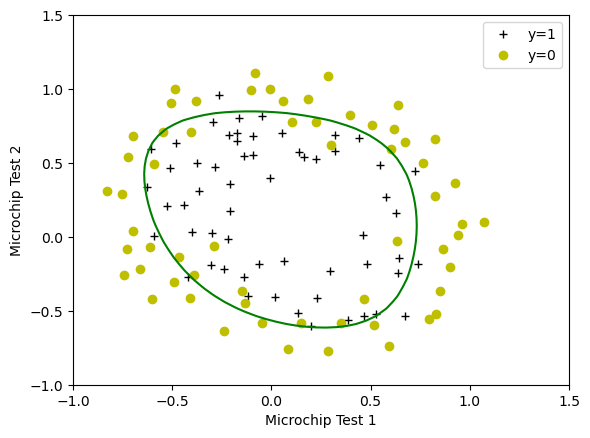

In [46]:
plot_decision_boundary(w, b, X_mapped, y_train)

plt.ylabel('Microchip Test 2')
plt.xlabel('Microchip Test 1') 
plt.legend(loc="upper right")
plt.savefig("plot.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

---

## Evaluating the Model

In [44]:
def predict(X, w, b):    # Predict whether the label is 0 or 1 using learned logistic regression parameters w
    m, n = X.shape
    p = np.zeros(m)

    for i in range(m):
        z_wb = 0
        for j in range(n):
            z_wb += w[j]*X[i][j]

        z_wb += b
        f_wb = sigmoid(z_wb)
        p[i] = f_wb >= 0.5
    return p

In [45]:
p = predict(X_mapped, w, b)

print('Train Accuracy: %f'%(np.mean(p == y_train) * 100))

Train Accuracy: 82.203390


---